# NB04 — Training & Evaluasi

Melatih dan mengevaluasi model forecasting 24 jam ke depan (8 titik, setiap 3 jam).

**Input:** `data/processed/model_dataset.csv` dan `data/processed/model_config.json` (hasil NB03)
**Output:** model di `models/rf_multioutput/`, metrik dan grafik di `outputs/evaluation/`

Setiap cell diberi kode `[NB04-Cxx]` dan diakhiri dengan `✓ [NB04-Cxx] selesai`.

### Model & baseline

| Nama | Isi | Peran |
|---|---|---|
| **Persistence** | forecast = nilai titik grafik sekarang | baseline |
| **Kemarin jam sama** | forecast = nilai titik grafik 24 jam sebelum waktu target | baseline |
| **RF 6 model** | 1 Random Forest per polutan, sekali jalan menghasilkan 8 titik | **model utama** |

### Cara menebak per polutan (pilihan B)

| Polutan | Cara | Yang ditebak model |
|---|---|---|
| PM2.5, PM10, CO | **koreksi** | selisih dari "kemarin jam sama"; forecast = kemarin jam sama + koreksi |
| O3, SO2, NO2 | **langsung** | nilai polutan langsung |

Pembagian ini dipilih dari hasil **validation** (uji cepat sebelumnya).

### Aturan evaluasi
- Model dilatih memakai **semua jam** sebagai origin, tetapi dievaluasi hanya pada **origin jam grid** (02, 05, 08, … WITA), sesuai pemakaian nyata.
- Model dan baseline dievaluasi pada **baris yang sama**. Baseline dipakai sebagai tolok ukur: model yang baik harus lebih akurat dari baseline.
- Baris yang targetnya melewati batas split dibuang (tidak ada kebocoran data).

In [1]:
# ============================================================
# [NB04-C01] SETUP & KONFIGURASI
# ============================================================

from pathlib import Path
import json
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid

warnings.filterwarnings("ignore")

PROCESSED_DIR = Path("../data/processed")
DATASET_PATH = PROCESSED_DIR / "model_dataset.csv"
CONFIG_PATH = PROCESSED_DIR / "model_config.json"

MODEL_DIR = Path("../models/rf_multioutput")
EVAL_DIR = Path("../outputs/evaluation")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
EVAL_DIR.mkdir(parents=True, exist_ok=True)

assert DATASET_PATH.exists(), f"Jalankan NB03 dulu. File tidak ditemukan: {DATASET_PATH}"

with open(CONFIG_PATH, encoding="utf-8") as f:
    config = json.load(f)

DEVICE_COL = "ispu_device_id"
POLLUTANTS = config["pollutants"]
HORIZONS = config["horizons"]
FEATURE_COLS = config["feature_cols"]
TRAIN_END = pd.Timestamp(config["train_end"])
VAL_END = pd.Timestamp(config["val_end"])

RANDOM_STATE = 42

# Polutan yang memakai cara KOREKSI: model menebak selisih dari "kemarin jam sama",
# forecast = kemarin jam sama + koreksi. Polutan lain memakai cara LANGSUNG.
CORRECTION_POLLUTANTS = ["PM25", "PM10", "CO"]

# Parameter awal Random Forest (sebelum tuning)
BASE_RF_PARAMS = {
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_leaf": 5,
    "max_features": 0.5,
}

# Kombinasi yang diuji saat tuning (per polutan)
TUNING_GRID = {
    "n_estimators": [200],
    "max_depth": [None, 15],
    "min_samples_leaf": [3, 10],
    "max_features": [0.3, 0.6],
}

# Warna grafik (urutan tetap)
COLOR_ACTUAL = "#2a78d6"
COLOR_SERIES_2 = "#eb6834"
COLOR_SERIES_3 = "#1baf7a"
COLOR_TEXT = "#52514e"
COLOR_GRID = "#e4e3df"

print("CPU tersedia       :", os.cpu_count())
print("Polutan            :", POLLUTANTS)
print("Horizon utama      :", HORIZONS)
print("Jumlah fitur       :", len(FEATURE_COLS))
print("Batas train        :", TRAIN_END)
print("Batas validation   :", VAL_END)
print("Cara koreksi       :", CORRECTION_POLLUTANTS)
print("Cara langsung      :", [p for p in POLLUTANTS if p not in CORRECTION_POLLUTANTS])

print("\n✓ [NB04-C01] selesai")

CPU tersedia       : 8
Polutan            : ['PM25', 'PM10', 'CO', 'O3', 'SO2', 'NO2']
Horizon utama      : [3, 6, 9, 12, 15, 18, 21, 24]
Jumlah fitur       : 115
Batas train        : 2026-08-07 14:00:00
Batas validation   : 2026-08-30 00:00:00
Cara koreksi       : ['PM25', 'PM10', 'CO']
Cara langsung      : ['O3', 'SO2', 'NO2']

✓ [NB04-C01] selesai


In [2]:
# ============================================================
# [NB04-C02] LOAD DATASET MODEL
# ============================================================

df = pd.read_csv(DATASET_PATH, parse_dates=["hour_wita", "origin_time"])
df = df.sort_values([DEVICE_COL, "origin_time"]).reset_index(drop=True)

TEST_END = df["origin_time"].max()
SPLIT_END = {"train": TRAIN_END, "val": VAL_END, "test": TEST_END}

missing_features = set(FEATURE_COLS) - set(df.columns)
assert not missing_features, f"Fitur tidak ada di dataset: {missing_features}"

print("Shape:", df.shape)
print("\nJumlah baris per split:")
print(df["split"].value_counts()[["train", "val", "test"]].to_string())

print("\n✓ [NB04-C02] selesai")

Shape: (17930, 186)

Jumlah baris per split:
split
train    12550
val       2690
test      2690

✓ [NB04-C02] selesai


In [3]:
# ============================================================
# [NB04-C03] BASELINE: PERSISTENCE & KEMARIN JAM SAMA
# ============================================================
# Persistence      : forecast semua horizon = nilai titik grafik pada origin
# Kemarin jam sama : forecast +h = nilai titik grafik pada (origin + h - 24 jam)

def target_cols(pollutant, horizons=HORIZONS):
    return [f"{pollutant}_target_{h}h" for h in horizons]


def seasonal_col(pollutant, h):
    return f"{pollutant}_seasonal_{h}h"


for p in POLLUTANTS:
    block = f"{p}_block3h"
    for h in HORIZONS:
        # geser ke hari sebelumnya yang sudah terjadi
        back = int(np.ceil(h / 24) * 24 - h)
        df[seasonal_col(p, h)] = df.groupby(DEVICE_COL)[block].shift(back)

# Cek: baseline "kemarin" untuk +3 jam = titik grafik 21 jam sebelum origin
row = df[df["PM25_seasonal_3h"].notna()].iloc[1000]
dev = df[df[DEVICE_COL] == row[DEVICE_COL]].set_index("origin_time")
manual = dev.loc[row["origin_time"] - pd.Timedelta(hours=21), "PM25_block3h"]
assert np.isclose(row["PM25_seasonal_3h"], manual)

print("Kolom baseline dibuat untuk", len(POLLUTANTS), "polutan ×", len(HORIZONS), "horizon")
print("Cek manual baseline 'kemarin jam sama' lolos.")

print("\n✓ [NB04-C03] selesai")

Kolom baseline dibuat untuk 6 polutan × 8 horizon
Cek manual baseline 'kemarin jam sama' lolos.

✓ [NB04-C03] selesai


In [4]:
# ============================================================
# [NB04-C04] FUNGSI BANTU & DATA EVALUASI
# ============================================================

def select_rows(splits, pollutant, horizons=HORIZONS, grid_only=False, need_baseline=False):
    """Ambil baris dengan fitur lengkap, target lengkap, dan target tidak melewati batas split."""
    splits = [splits] if isinstance(splits, str) else list(splits)
    end = max(SPLIT_END[s] for s in splits)

    mask = df["split"].isin(splits)
    mask &= df[FEATURE_COLS].notna().all(axis=1)
    mask &= df[target_cols(pollutant, horizons)].notna().all(axis=1)
    mask &= df["origin_time"] + pd.Timedelta(hours=max(horizons)) <= end

    if grid_only:
        mask &= df["is_grid_origin"]

    if need_baseline:
        mask &= df[f"{pollutant}_block3h"].notna()
        mask &= df[[seasonal_col(pollutant, h) for h in horizons]].notna().all(axis=1)

    return df[mask]


def evaluate(y_true, y_pred, pollutant, horizons, method, split):
    """Hitung MAE, RMSE, R² untuk setiap horizon."""
    y_true = np.asarray(y_true, dtype=float).reshape(-1, len(horizons))
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1, len(horizons))
    rows = []
    for i, h in enumerate(horizons):
        rows.append({
            "method": method,
            "split": split,
            "pollutant": pollutant,
            "horizon": h,
            "MAE": mean_absolute_error(y_true[:, i], y_pred[:, i]),
            "RMSE": np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i])),
            "R2": r2_score(y_true[:, i], y_pred[:, i]),
            "n": len(y_true),
        })
    return rows


def baseline_predictions(rows, pollutant, horizons=HORIZONS):
    persistence = np.repeat(rows[[f"{pollutant}_block3h"]].values, len(horizons), axis=1)
    seasonal = rows[[seasonal_col(pollutant, h) for h in horizons]].values
    return persistence, seasonal


def make_rf(params):
    return RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)


def is_correction(pollutant):
    return pollutant in CORRECTION_POLLUTANTS


def seasonal_values(rows, pollutant):
    return rows[[seasonal_col(pollutant, h) for h in HORIZONS]].values


def train_rows(splits, pollutant):
    """Baris training. Cara koreksi butuh nilai 'kemarin jam sama' yang tersedia."""
    return select_rows(splits, pollutant, need_baseline=is_correction(pollutant))


def fit_model(params, rows, pollutant):
    y = rows[target_cols(pollutant)].values
    if is_correction(pollutant):
        y = y - seasonal_values(rows, pollutant)      # model belajar selisihnya
    return make_rf(params).fit(rows[FEATURE_COLS], y)


def predict_model(model, rows, pollutant):
    pred = model.predict(rows[FEATURE_COLS])
    if is_correction(pollutant):
        pred = pred + seasonal_values(rows, pollutant)  # kembalikan ke nilai polutan
    return pred


# Data evaluasi: origin jam grid, dipakai bersama oleh semua metode
EVAL_SETS = {
    split: {p: select_rows(split, p, grid_only=True, need_baseline=True) for p in POLLUTANTS}
    for split in ["val", "test"]
}

eval_size = pd.DataFrame({
    split: {p: len(EVAL_SETS[split][p]) for p in POLLUTANTS} for split in EVAL_SETS
})
print("Jumlah baris evaluasi (origin jam grid):")
print(eval_size.to_string())

print("\n✓ [NB04-C04] selesai")

Jumlah baris evaluasi (origin jam grid):
      val  test
PM25  719   772
PM10  719   772
CO    719   772
O3    719   772
SO2   719   772
NO2   719   772

✓ [NB04-C04] selesai


In [5]:
# ============================================================
# [NB04-C05] EVALUASI BASELINE (VALIDATION)
# ============================================================

val_results = []

for p in POLLUTANTS:
    ev = EVAL_SETS["val"][p]
    y_true = ev[target_cols(p)].values
    persistence, seasonal = baseline_predictions(ev, p)

    val_results += evaluate(y_true, persistence, p, HORIZONS, "Persistence", "val")
    val_results += evaluate(y_true, seasonal, p, HORIZONS, "Kemarin jam sama", "val")

baseline_val = pd.DataFrame(val_results)
print("Rata-rata R² validation (8 horizon):")
print(baseline_val.pivot_table(index="pollutant", columns="method", values="R2").round(3).to_string())

print("\n✓ [NB04-C05] selesai")

Rata-rata R² validation (8 horizon):
method     Kemarin jam sama  Persistence
pollutant                               
CO                    0.318       -0.162
NO2                   0.915        0.184
O3                    0.911        0.266
PM10                  0.618        0.007
PM25                  0.554        0.026
SO2                   0.463        0.246

✓ [NB04-C05] selesai


In [6]:
# ============================================================
# [NB04-C06] MODEL UTAMA: RF 6 MODEL (TRAIN → VALIDATION)
# ============================================================
# 1 model per polutan, output 8 kolom target sekaligus (multi-output)

print("=== RF 6 MODEL ===\n")

for i, p in enumerate(POLLUTANTS, start=1):
    train = train_rows("train", p)
    ev = EVAL_SETS["val"][p]

    t0 = time.time()
    model = fit_model(BASE_RF_PARAMS, train, p)
    pred = predict_model(model, ev, p)

    val_results += evaluate(ev[target_cols(p)].values, pred, p, HORIZONS, "RF 6 model", "val")

    r2_mean = np.mean([r2_score(ev[c], pred[:, j]) for j, c in enumerate(target_cols(p))])
    cara = "koreksi" if is_correction(p) else "langsung"
    print(f"[{i}/6] RF_{p:<5} ({cara:<8}) train={len(train):>6} | R² rata-rata={r2_mean:.3f} | {time.time() - t0:.1f} detik")

print("\n✓ [NB04-C06] selesai")

=== RF 6 MODEL ===

[1/6] RF_PM25  (koreksi ) train=  7920 | R² rata-rata=0.569 | 29.0 detik
[2/6] RF_PM10  (koreksi ) train=  7920 | R² rata-rata=0.643 | 24.5 detik
[3/6] RF_CO    (koreksi ) train=  7920 | R² rata-rata=0.332 | 26.4 detik
[4/6] RF_O3    (langsung) train=  7920 | R² rata-rata=0.927 | 23.5 detik
[5/6] RF_SO2   (langsung) train=  7920 | R² rata-rata=0.494 | 41.2 detik
[6/6] RF_NO2   (langsung) train=  7920 | R² rata-rata=0.930 | 15.5 detik

✓ [NB04-C06] selesai


In [7]:
# ============================================================
# [NB04-C07] RF 6 MODEL vs BASELINE (VALIDATION)
# ============================================================

val_df = pd.DataFrame(val_results)

method_order = ["Persistence", "Kemarin jam sama", "RF 6 model"]

print("=== R² RATA-RATA 8 HORIZON (semakin tinggi semakin baik) ===")
r2_table = val_df.pivot_table(index="pollutant", columns="method", values="R2")[method_order]
r2_table.loc["RATA-RATA"] = r2_table.mean()
print(r2_table.round(3).to_string())

print("\n=== MAE RATA-RATA 8 HORIZON (semakin rendah semakin baik) ===")
mae_table = val_df.pivot_table(index="pollutant", columns="method", values="MAE")[method_order]
print(mae_table.round(2).to_string())

print("\n=== R² PER HORIZON (rata-rata 6 polutan) ===")
print(val_df.pivot_table(index="horizon", columns="method", values="R2")[method_order].round(3).to_string())

best = r2_table.drop("RATA-RATA").idxmax(axis=1)
print("\nMetode terbaik per polutan (R² validation):")
print(best.to_string())

print("\n✓ [NB04-C07] selesai")

=== R² RATA-RATA 8 HORIZON (semakin tinggi semakin baik) ===
method     Persistence  Kemarin jam sama  RF 6 model
pollutant                                           
CO              -0.162             0.318       0.332
NO2              0.184             0.915       0.930
O3               0.266             0.911       0.927
PM10             0.007             0.618       0.643
PM25             0.026             0.554       0.569
SO2              0.246             0.463       0.494
RATA-RATA        0.095             0.630       0.649

=== MAE RATA-RATA 8 HORIZON (semakin rendah semakin baik) ===
method     Persistence  Kemarin jam sama  RF 6 model
pollutant                                           
CO              136.01             88.12       87.47
NO2              12.45              3.42        3.24
O3               14.83              4.16        4.44
PM10             35.06             19.42       18.51
PM25             18.14             11.06       10.70
SO2               0.46      

In [8]:
# ============================================================
# [NB04-C08] TUNING RF 6 MODEL (PER POLUTAN, VALIDATION)
# ============================================================
# Kriteria: MAE rata-rata 8 horizon pada validation (semakin rendah semakin baik)

grid = list(ParameterGrid(TUNING_GRID))
print(f"Kombinasi per polutan: {len(grid)} | total training: {len(grid) * len(POLLUTANTS)}\n")

tuning_rows = []
BEST_PARAMS = {}
t_all = time.time()

for p in POLLUTANTS:
    train = train_rows("train", p)
    ev = EVAL_SETS["val"][p]

    for params in grid:
        model = fit_model(params, train, p)
        pred = predict_model(model, ev, p)
        res = pd.DataFrame(evaluate(ev[target_cols(p)].values, pred, p, HORIZONS, "tuning", "val"))
        tuning_rows.append({"pollutant": p, **params, "MAE": res["MAE"].mean(), "R2": res["R2"].mean()})

    p_rows = pd.DataFrame([r for r in tuning_rows if r["pollutant"] == p])
    best_row = p_rows.sort_values("MAE").iloc[0]
    BEST_PARAMS[p] = {key: best_row[key] for key in TUNING_GRID}
    BEST_PARAMS[p]["n_estimators"] = int(BEST_PARAMS[p]["n_estimators"])
    BEST_PARAMS[p]["min_samples_leaf"] = int(BEST_PARAMS[p]["min_samples_leaf"])
    if pd.isna(BEST_PARAMS[p]["max_depth"]):
        BEST_PARAMS[p]["max_depth"] = None
    else:
        BEST_PARAMS[p]["max_depth"] = int(BEST_PARAMS[p]["max_depth"])

    print(f"{p:<5} terbaik: {BEST_PARAMS[p]} | MAE={best_row['MAE']:.3f} R²={best_row['R2']:.3f} "
          f"({time.time() - t_all:.0f} detik)")

tuning_df = pd.DataFrame(tuning_rows)

# Bandingkan dengan parameter awal
base = val_df[val_df["method"] == "RF 6 model"].groupby("pollutant")[["MAE", "R2"]].mean()
tuned = tuning_df.sort_values("MAE").groupby("pollutant").first()[["MAE", "R2"]]
compare = base.join(tuned, lsuffix="_awal", rsuffix="_tuning")
compare["MAE_turun_%"] = (1 - compare["MAE_tuning"] / compare["MAE_awal"]) * 100
print("\nParameter awal vs hasil tuning:")
print(compare.round(3).to_string())

print("\n✓ [NB04-C08] selesai")

Kombinasi per polutan: 8 | total training: 48

PM25  terbaik: {'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 3, 'max_features': np.float64(0.6)} | MAE=10.652 R²=0.571 (171 detik)
PM10  terbaik: {'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 3, 'max_features': np.float64(0.3)} | MAE=18.490 R²=0.645 (326 detik)
CO    terbaik: {'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 3, 'max_features': np.float64(0.3)} | MAE=87.206 R²=0.332 (496 detik)
O3    terbaik: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 3, 'max_features': np.float64(0.6)} | MAE=4.427 R²=0.927 (635 detik)
SO2   terbaik: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 10, 'max_features': np.float64(0.3)} | MAE=0.479 R²=0.555 (838 detik)
NO2   terbaik: {'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 10, 'max_features': np.float64(0.6)} | MAE=3.230 R²=0.930 (938 detik)

Parameter awal vs hasil tuning:
           MAE_awal  R2_awal  MAE_tuning  R2_tuning  

In [9]:
# ============================================================
# [NB04-C09] TRAINING FINAL (TRAIN + VALIDATION) → EVALUASI TEST
# ============================================================

test_results = []
test_preds = {}

print("=== EVALUASI TEST ===\n")

for i, p in enumerate(POLLUTANTS, start=1):
    train_val = train_rows(["train", "val"], p)
    ev = EVAL_SETS["test"][p]
    y_true = ev[target_cols(p)].values

    model = fit_model(BEST_PARAMS[p], train_val, p)
    pred = predict_model(model, ev, p)
    test_preds[p] = pred

    persistence, seasonal = baseline_predictions(ev, p)
    test_results += evaluate(y_true, pred, p, HORIZONS, "RF 6 model", "test")
    test_results += evaluate(y_true, persistence, p, HORIZONS, "Persistence", "test")
    test_results += evaluate(y_true, seasonal, p, HORIZONS, "Kemarin jam sama", "test")

    r2_mean = np.mean([r2_score(y_true[:, j], pred[:, j]) for j in range(len(HORIZONS))])
    print(f"[{i}/6] RF_{p:<5} train+val={len(train_val):>6} | test={len(ev):>4} | R² rata-rata={r2_mean:.3f}")

test_df = pd.DataFrame(test_results)

print("\n✓ [NB04-C09] selesai")

=== EVALUASI TEST ===

[1/6] RF_PM25  train+val= 10148 | test= 772 | R² rata-rata=0.426
[2/6] RF_PM10  train+val= 10148 | test= 772 | R² rata-rata=0.504
[3/6] RF_CO    train+val= 10148 | test= 772 | R² rata-rata=0.208
[4/6] RF_O3    train+val= 10148 | test= 772 | R² rata-rata=0.895
[5/6] RF_SO2   train+val= 10148 | test= 772 | R² rata-rata=0.079
[6/6] RF_NO2   train+val= 10148 | test= 772 | R² rata-rata=0.927

✓ [NB04-C09] selesai


In [2]:
print(test_results)

NameError: name 'test_results' is not defined

In [10]:
# ============================================================
# [NB04-C10] RINGKASAN HASIL TEST
# ============================================================

rf_test = test_df[test_df["method"] == "RF 6 model"]

print("=== R² TEST PER POLUTAN × HORIZON (RF 6 model) ===")
print(rf_test.pivot_table(index="pollutant", columns="horizon", values="R2").round(3).to_string())

print("\n=== MAE TEST PER POLUTAN × HORIZON (RF 6 model) ===")
print(rf_test.pivot_table(index="pollutant", columns="horizon", values="MAE").round(2).to_string())

print("\n=== RF vs BASELINE (rata-rata 8 horizon, test) ===")
summary = test_df.pivot_table(index="pollutant", columns="method", values=["R2", "MAE"])
summary[("MAE", "Perbaikan vs persistence %")] = (
    1 - summary[("MAE", "RF 6 model")] / summary[("MAE", "Persistence")]
) * 100
print(summary.round(3).to_string())

# Akurasi per sensor
print("\n=== R² TEST PER SENSOR (rata-rata 8 horizon, RF 6 model) ===")
per_sensor = []
for p in POLLUTANTS:
    ev = EVAL_SETS["test"][p]
    for s in sorted(ev[DEVICE_COL].unique()):
        m = (ev[DEVICE_COL] == s).values
        res = evaluate(ev.loc[m, target_cols(p)].values, test_preds[p][m], p, HORIZONS, "RF 6 model", "test")
        per_sensor.append({"sensor": s, "pollutant": p, "R2": np.mean([r["R2"] for r in res])})
print(pd.DataFrame(per_sensor).pivot_table(index="sensor", columns="pollutant", values="R2").round(3).to_string())

print("\n✓ [NB04-C10] selesai")

=== R² TEST PER POLUTAN × HORIZON (RF 6 model) ===
horizon       3      6      9      12     15     18     21     24
pollutant                                                        
CO         0.202  0.212  0.179  0.155  0.174  0.186  0.211  0.345
NO2        0.931  0.927  0.928  0.927  0.926  0.925  0.926  0.924
O3         0.929  0.905  0.899  0.893  0.892  0.882  0.881  0.882
PM10       0.599  0.503  0.500  0.478  0.478  0.464  0.478  0.528
PM25       0.491  0.433  0.430  0.384  0.388  0.389  0.399  0.494
SO2        0.166  0.089  0.067  0.043  0.064  0.076  0.074  0.051

=== MAE TEST PER POLUTAN × HORIZON (RF 6 model) ===
horizon        3       6       9       12      15      18      21      24
pollutant                                                                
CO         189.20  198.24  208.98  208.11  206.09  199.56  199.46  179.35
NO2          3.14    3.32    3.33    3.34    3.33    3.40    3.38    3.40
O3           3.92    4.66    4.88    5.04    5.09    5.42    5.39    5.3

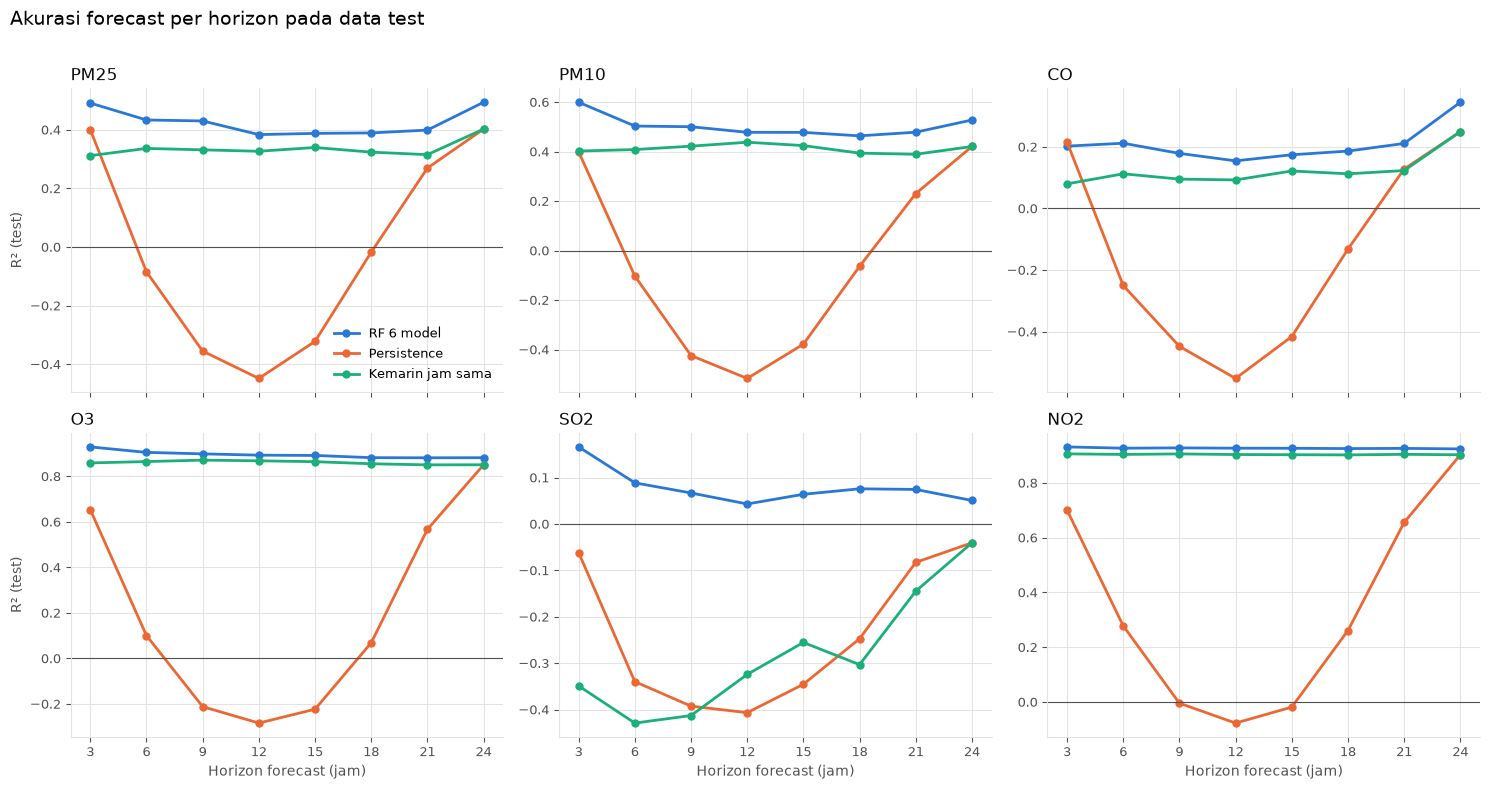

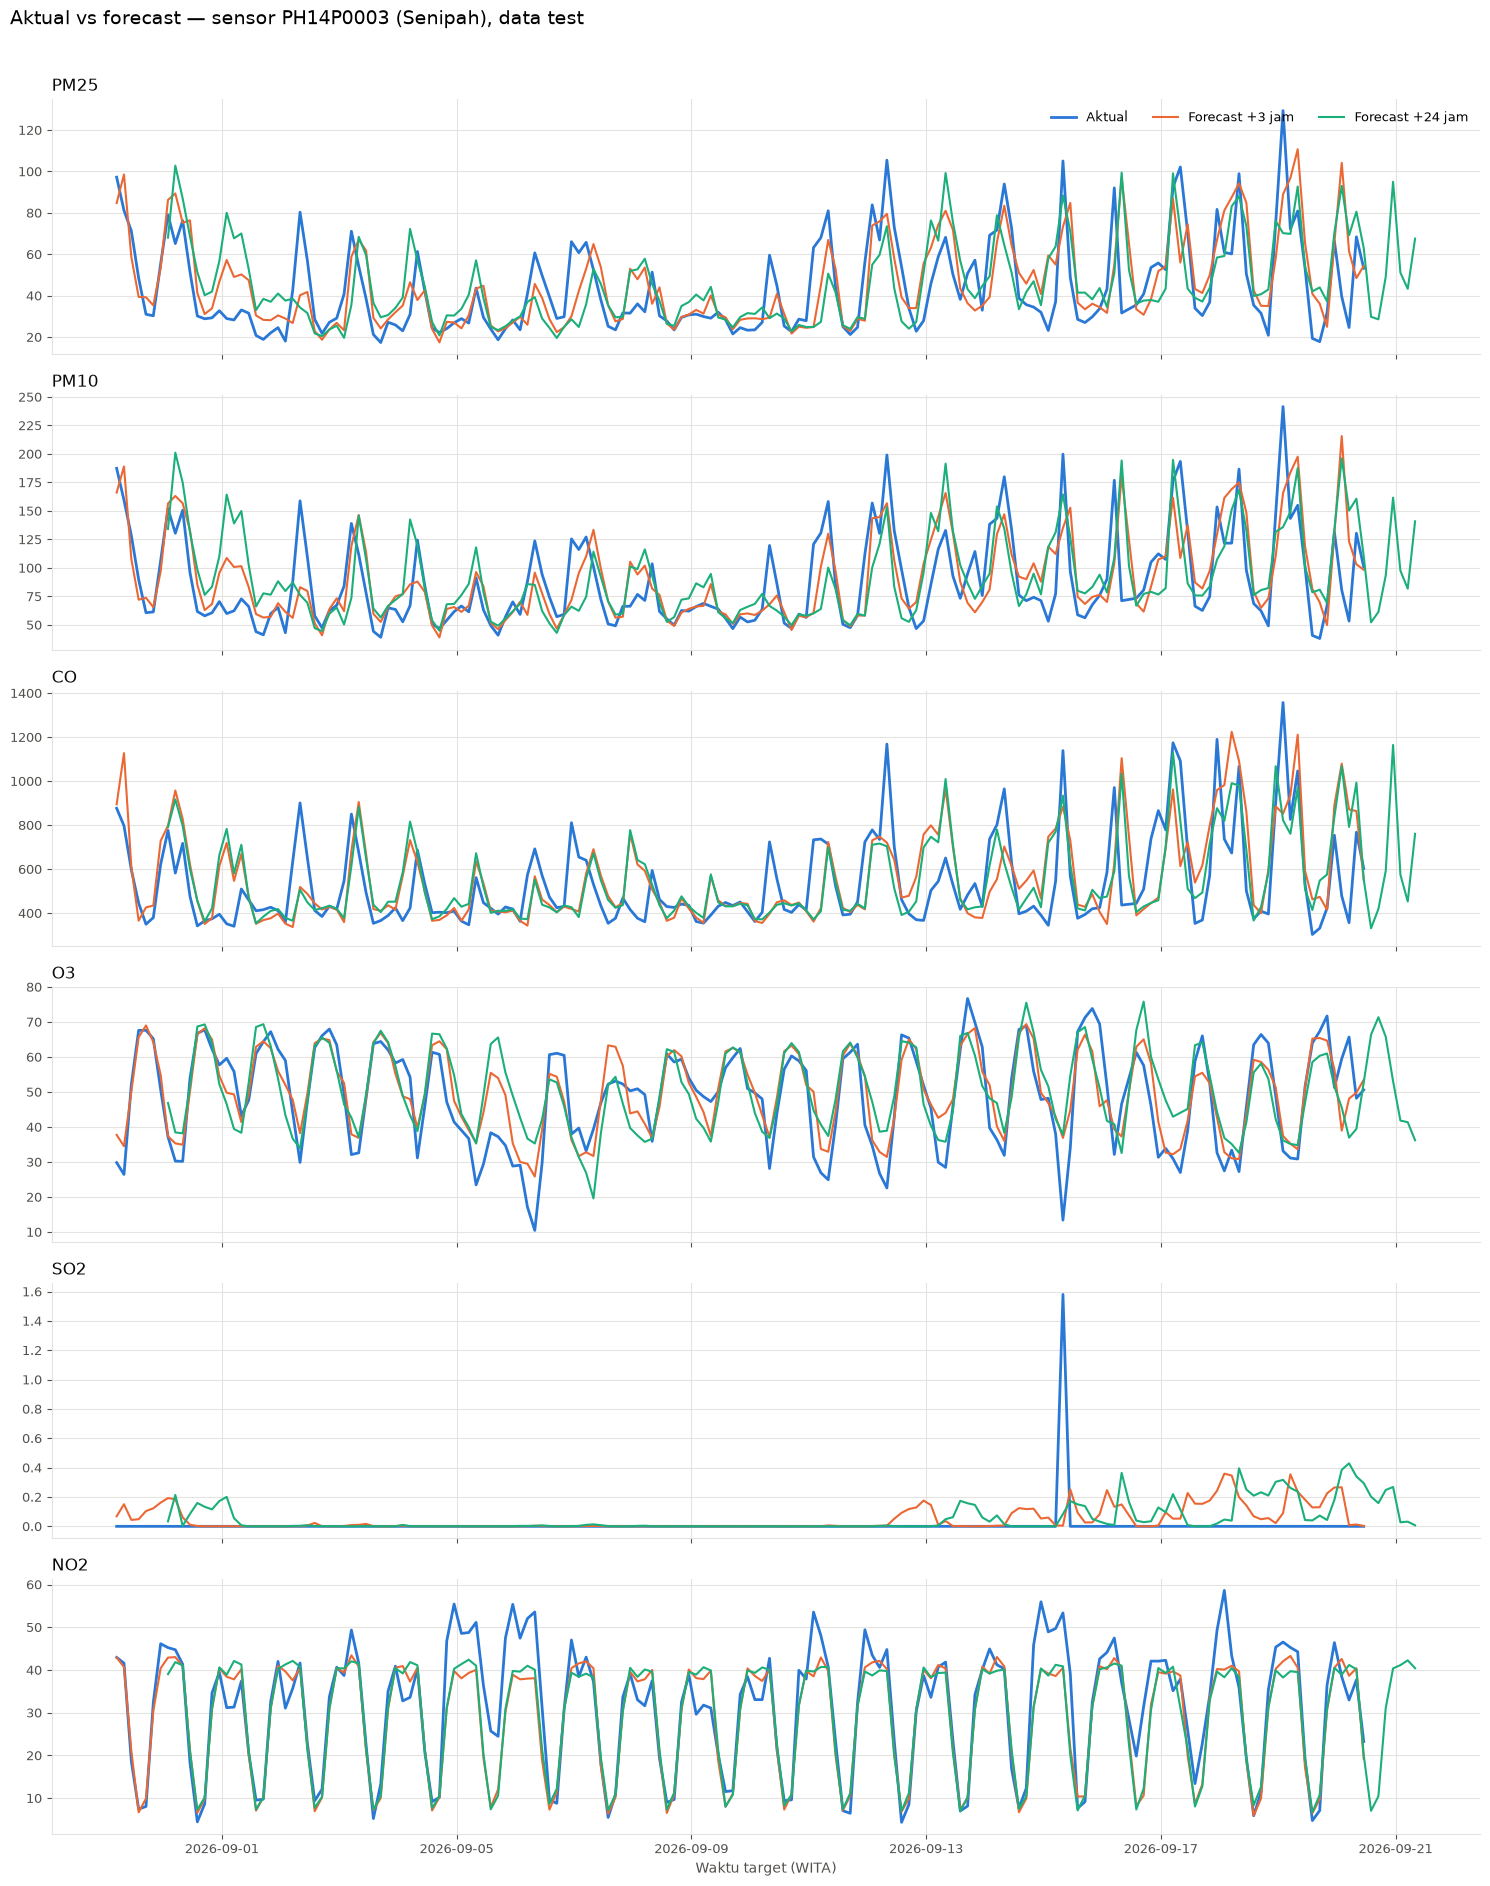

Grafik disimpan di: C:\Users\ASUS\Documents\KP\forecastispu-forecastclaude\outputs\evaluation

✓ [NB04-C11] selesai


In [11]:
# ============================================================
# [NB04-C11] GRAFIK: R² PER HORIZON & AKTUAL VS FORECAST
# ============================================================

def style_axis(ax):
    ax.grid(True, color=COLOR_GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color(COLOR_GRID)
    ax.tick_params(colors=COLOR_TEXT, labelsize=9)


# 1. R² per horizon: RF vs baseline (satu panel per polutan)
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
series = [
    ("RF 6 model", COLOR_ACTUAL),
    ("Persistence", COLOR_SERIES_2),
    ("Kemarin jam sama", COLOR_SERIES_3),
]
for ax, p in zip(axes.flat, POLLUTANTS):
    for method, color in series:
        d = test_df[(test_df["method"] == method) & (test_df["pollutant"] == p)].sort_values("horizon")
        ax.plot(d["horizon"], d["R2"], color=color, linewidth=2, marker="o", markersize=5, label=method)
    ax.axhline(0, color=COLOR_TEXT, linewidth=0.8)
    ax.set_title(p, fontsize=12, color="#0b0b0b", loc="left")
    ax.set_xticks(HORIZONS)
    style_axis(ax)
for ax in axes[1]:
    ax.set_xlabel("Horizon forecast (jam)", color=COLOR_TEXT)
for ax in axes[:, 0]:
    ax.set_ylabel("R² (test)", color=COLOR_TEXT)
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle("Akurasi forecast per horizon pada data test", fontsize=14, x=0.01, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(EVAL_DIR / "r2_per_horizon.png", dpi=150)
plt.show()

# 2. Aktual vs forecast pada satu sensor (titik grafik, origin jam grid)
example_sensor = "PH14P0003"
fig, axes = plt.subplots(len(POLLUTANTS), 1, figsize=(15, 3.2 * len(POLLUTANTS)), sharex=True)
for ax, p in zip(axes, POLLUTANTS):
    ev = EVAL_SETS["test"][p]
    m = (ev[DEVICE_COL] == example_sensor).values
    ev_s = ev[m]
    pred_s = test_preds[p][m]

    for j, (h, color) in enumerate([(3, COLOR_SERIES_2), (24, COLOR_SERIES_3)]):
        idx = HORIZONS.index(h)
        target_time = ev_s["origin_time"] + pd.Timedelta(hours=h)
        if j == 0:
            ax.plot(target_time, ev_s[f"{p}_target_{h}h"], color=COLOR_ACTUAL, linewidth=2, label="Aktual")
        ax.plot(target_time, pred_s[:, idx], color=color, linewidth=1.5, label=f"Forecast +{h} jam")

    ax.set_title(p, fontsize=12, color="#0b0b0b", loc="left")
    style_axis(ax)
axes[0].legend(frameon=False, fontsize=9, ncol=3, loc="upper right")
axes[-1].set_xlabel("Waktu target (WITA)", color=COLOR_TEXT)
fig.suptitle(f"Aktual vs forecast — sensor {example_sensor} (Senipah), data test", fontsize=14, x=0.01, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(EVAL_DIR / f"actual_vs_forecast_{example_sensor}.png", dpi=150)
plt.show()

print("Grafik disimpan di:", EVAL_DIR.resolve())

print("\n✓ [NB04-C11] selesai")

In [12]:
# ============================================================
# [NB04-C12] TRAINING ULANG DENGAN SEMUA DATA & SIMPAN MODEL
# ============================================================
# Setelah akurasi diketahui dari data test, model final dilatih ulang
# memakai seluruh data (train + validation + test) agar memakai data terbaru.

saved = []

for p in POLLUTANTS:
    all_rows = train_rows(["train", "val", "test"], p)
    model = fit_model(BEST_PARAMS[p], all_rows, p)

    path = MODEL_DIR / f"RF_{p}.joblib"
    joblib.dump(model, path, compress=3)

    # Verifikasi: model yang di-load menghasilkan prediksi yang sama
    loaded = joblib.load(path)
    sample = all_rows.tail(5)
    assert np.allclose(predict_model(model, sample, p), predict_model(loaded, sample, p))

    saved.append({
        "model": path.name,
        "cara": "koreksi" if is_correction(p) else "langsung",
        "baris_training": len(all_rows),
        "data_sampai": str(all_rows["origin_time"].max()),
        "ukuran_MB": round(path.stat().st_size / 1e6, 1),
    })

print(pd.DataFrame(saved).to_string(index=False))

metadata = {
    "model_type": "RandomForestRegressor (multi-output)",
    "pollutants": POLLUTANTS,
    "horizons": HORIZONS,
    "outputs_per_model": target_cols("<POLUTAN>"),
    "feature_cols": FEATURE_COLS,
    "best_params": BEST_PARAMS,
    "target_mode": {p: ("koreksi" if is_correction(p) else "langsung") for p in POLLUTANTS},
    "target_mode_note": "koreksi: forecast = nilai titik grafik (origin + h - 24 jam) + prediksi model",
    "db_to_wita_hours": config["db_to_wita_hours"],
    "grid_hours_wita": config["grid_hours_wita"],
    "test_period": [str(VAL_END + pd.Timedelta(hours=1)), str(TEST_END)],
    "test_r2_mean": rf_test.groupby("pollutant")["R2"].mean().round(4).to_dict(),
    "test_mae_mean": rf_test.groupby("pollutant")["MAE"].mean().round(4).to_dict(),
}
with open(MODEL_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

val_df.to_csv(EVAL_DIR / "validation_results.csv", index=False)
tuning_df.to_csv(EVAL_DIR / "tuning_results.csv", index=False)
test_df.to_csv(EVAL_DIR / "test_results.csv", index=False)

print("\nModel disimpan di :", MODEL_DIR.resolve())
print("Metrik disimpan di:", EVAL_DIR.resolve())

print("\n✓ [NB04-C12] selesai")

         model     cara  baris_training         data_sampai  ukuran_MB
RF_PM25.joblib  koreksi           12558 2026-09-20 10:00:00        7.8
RF_PM10.joblib  koreksi           12542 2026-09-20 10:00:00       13.2
  RF_CO.joblib  koreksi           12558 2026-09-20 10:00:00        4.8
  RF_O3.joblib langsung           12558 2026-09-20 10:00:00       60.7
 RF_SO2.joblib langsung           12558 2026-09-20 10:00:00       13.9
 RF_NO2.joblib langsung           12558 2026-09-20 10:00:00       19.6

Model disimpan di : C:\Users\ASUS\Documents\KP\forecastispu-forecastclaude\models\rf_multioutput
Metrik disimpan di: C:\Users\ASUS\Documents\KP\forecastispu-forecastclaude\outputs\evaluation

✓ [NB04-C12] selesai
